# Ground Truth Dataset Analysis

> **Note:** This ground truth is based on the **old version** of the DMP label schema.
> It was subsequently updated using a rule-based approach informed by suggestions from
> Becky (Product Manager) to better reflect the intended label structure.

Overview of the manually labeled DMP samples and comparison with model predictions.
**Dataset:** \data/input/ground_truth_old_version/\ · 10 samples · 5 label types

In [1]:
from dmpbridge.evaluation.evaluate import extract_gold, MANUAL_DIR, load_method, confusion_matrix_df
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from pathlib import Path

LABELS     = ['title', 'section.title', 'section.description', 'question.text', 'answer.text']
SHORT      = ['title', 'sec.title', 'sec.desc', 'q.text', 'ans.text']
COLORS     = ['#1e3a5f', '#2563eb', '#60a5fa', '#f59e0b', '#10b981']
label_color = dict(zip(LABELS, COLORS))

rows = []
for i in range(1, 11):
    p = MANUAL_DIR / f'sample{i}_old_dmp.json'
    if not p.exists(): continue
    gold = extract_gold(p)
    counts = {lbl: 0 for lbl in LABELS}
    for _, lbl in gold:
        counts[lbl] += 1
    rows.append({'sample': f'sample{i}', **counts, 'total': len(gold)})

df_gt = pd.DataFrame(rows)
print('=== Ground Truth Label Counts per Sample ===')
print(df_gt.to_string(index=False))
print()
print('=== Totals ===')
for lbl in LABELS:
    print(f'  {lbl:<25} : {df_gt[lbl].sum():>4}')
print(f'  {"TOTAL":<25} : {df_gt["total"].sum():>4}')

=== Ground Truth Label Counts per Sample ===
  sample  title  section.title  section.description  question.text  answer.text  total
 sample1      1              6                    0              9           12     28
 sample2      1              4                    4              7            9     25
 sample3      1              5                    4              0            4     14
 sample4      1              0                    0              0            1      2
 sample5      1              6                    0              0            6     13
 sample6      1              5                    0              0            5     11
 sample7      1              0                    0              0            1      2
 sample8      1              6                    0              0            6     13
 sample9      1              5                    0              0            5     11
sample10      1              6                    0              0            6     1

## Label Distribution per Sample — Old Version
Each bar shows the breakdown of label types in that sample's ground truth (original annotations).

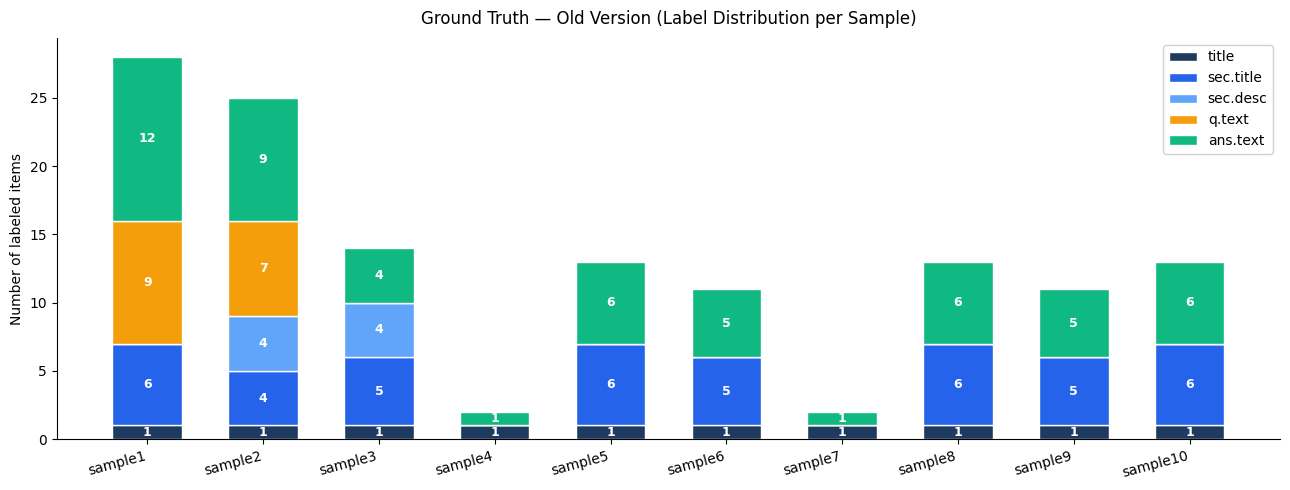

In [2]:
samples = df_gt['sample'].tolist()
x = range(len(samples))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = [0] * len(samples)

for lbl, color, short in zip(LABELS, COLORS, SHORT):
    vals = df_gt[lbl].tolist()
    bars = ax.bar(x, vals, bottom=bottom, color=color, label=short, width=0.6, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    str(v), ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels(samples, rotation=15, ha='right')
ax.set_ylabel('Number of labeled items')
ax.set_title('Ground Truth — Old Version (Label Distribution per Sample)', pad=10)
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

## Label Distribution per Sample — New Version
Same chart for the new version (after Becky's rule-based updates).

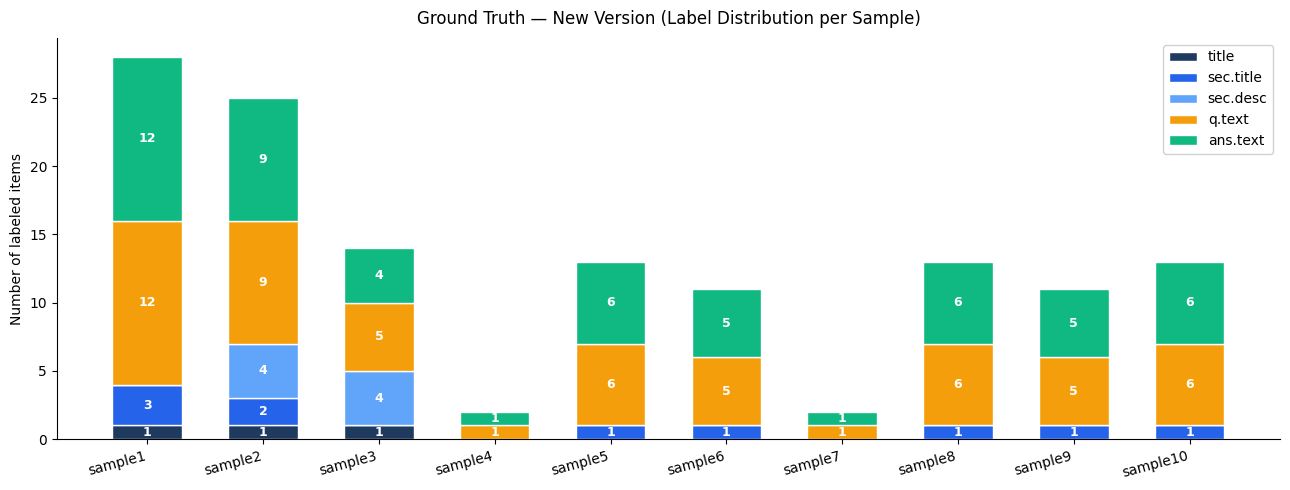

In [3]:
import json
from dmpbridge.evaluation.evaluate import NEW_MANUAL_DIR

def extract_gold_new(path):
    """Extract labels from new-version JSON. Always includes question.text,
    and omits section.title when it is duplicated as question.text."""
    data = json.loads(path.read_text(encoding='utf-8'))
    template = data.get('narrative', data).get('template', {})
    pairs = []

    title = template.get('title', '').strip()
    if title:
        pairs.append((title, 'title'))

    for section in template.get('section', []):
        sec_title = section.get('title', '').strip()
        q_texts = [q.get('text', '').strip() for q in section.get('question', [])]

        # Only keep section.title if it is NOT repeated as a question
        if sec_title and sec_title not in q_texts:
            pairs.append((sec_title, 'section.title'))

        if section.get('description'):
            pairs.append((section['description'].strip(), 'section.description'))

        for question in section.get('question', []):
            q_text = question.get('text', '').strip()
            if q_text:
                pairs.append((q_text, 'question.text'))
            ans = question.get('answer', {})
            ans_text = ''
            if isinstance(ans, dict):
                ans_text = ans.get('json', {}).get('answer', '') or ans.get('text', '')
            if ans_text:
                pairs.append((ans_text.strip(), 'answer.text'))

    return pairs

rows_new = []
for i in range(1, 11):
    p = NEW_MANUAL_DIR / f'sample{i}_new_dmp.json'
    if not p.exists(): continue
    gold = extract_gold_new(p)
    counts = {lbl: 0 for lbl in LABELS}
    for _, lbl in gold:
        counts[lbl] += 1
    rows_new.append({'sample': f'sample{i}', **counts, 'total': len(gold)})

df_new = pd.DataFrame(rows_new)
samples_new = df_new['sample'].tolist()
x = range(len(samples_new))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = [0] * len(samples_new)

for lbl, color, short in zip(LABELS, COLORS, SHORT):
    vals = df_new[lbl].tolist()
    bars = ax.bar(x, vals, bottom=bottom, color=color, label=short, width=0.6, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    str(v), ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels(samples_new, rotation=15, ha='right')
ax.set_ylabel('Number of labeled items')
ax.set_title('Ground Truth — New Version (Label Distribution per Sample)', pad=10)
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

---
## Rules: How to Convert Old Annotations → New Annotations

After comparing all 10 samples, **3 rules** cover all the changes Becky applied:

---

### Rule 1 — `section.title → question.text` *(80% of all changes, 36 cases)*
**When:** A section heading text is **exactly the same** as the question text inside that section.
**Why:** That text is really a question posed to the DMP author, not a structural document heading.
**Action:** Relabel it `question.text` instead of `section.title`.

```
Example:
  section.title = "Types of data"
  question.text = "Types of data"   ← same text
  → new label: question.text
```

---

### Rule 2 — `title → section.title` *(5 cases)*
**When:** The document title is a **generic DMP heading** (e.g. "DATA MANAGEMENT PLAN", "Data Management Plan") — not a specific research project name.
**Why:** A generic heading belongs at section level, not document level.
**Action:** Relabel it `section.title`.

```
Example:
  title = "Data Management Plan"   ← generic, not project-specific
  → new label: section.title
```

---

### Rule 3 — `title → question.text` *(2 cases)*
**When:** The document title is a **form prompt** rather than a real project name (e.g. "Resource/Data Sharing Plan").
**Why:** It reads as a question/instruction to the user, not an identifier.
**Action:** Relabel it `question.text`.

```
Example:
  title = "Resource/Data Sharing Plan"   ← sounds like a form field name
  → new label: question.text
```

In [4]:
import json

# ── Understand WHY Rule 1 can't be applied to the old JSON directly ──────────
# The old and new JSONs have different STRUCTURES, not just different labels.
# Old version: many flat sections, each with one empty question
# New version: fewer sections, with multiple questions nested inside

print("=== JSON Structure Comparison (sample5) ===\n")
for ver, fname in [("OLD", "ground_truth_old_version/sample5_old_dmp.json"),
                   ("NEW", "ground_truth_new_version/sample5_new_dmp.json")]:
    data = json.loads((MANUAL_DIR.parent / fname).read_text(encoding='utf-8'))
    sections = data['narrative']['template']['section']
    print(f"  {ver}: {len(sections)} section(s)")
    for s in sections:
        sec_t = s.get('title', '').strip()
        qs    = [q.get('text', '—').strip() or '—' for q in s.get('question', [])]
        print(f"    section.title = {repr(sec_t[:45])}")
        for qt in qs:
            print(f"      question.text = {repr(qt[:45])}")
    print()

print("─" * 65)
print("""
CONCLUSION — 3 rules observed, but they come from 2 different changes:

  Rule 1  (section.title → question.text, 36 cases)
      The JSON was RESTRUCTURED: what were separate sections
      in the old version became questions inside one parent section.
      The section titles became question texts.
      → Requires restructuring the JSON, not just relabeling.

  Rule 2  (title → section.title, 5 cases)
      Generic headings like "DATA MANAGEMENT PLAN" were demoted.
      → Can be applied as a label change to any new DMP.

  Rule 3  (title → question.text, 2 cases)
      Short form-prompt titles like "Resource/Data Sharing Plan".
      → Can be applied as a label change to any new DMP.
""")

=== JSON Structure Comparison (sample5) ===

  OLD: 6 section(s)
    section.title = 'REVIEW OF PROPOSAL COMPONENTS'
      question.text = '—'
    section.title = 'TYPES OF DATA'
      question.text = '—'
    section.title = 'DATA AND METADATA STANDARDS'
      question.text = '—'
    section.title = 'POLICIES FOR ACCESS AND SHARING'
      question.text = '—'
    section.title = 'POLICIES AND PROVISIONS FOR RE-USE, RE-DISTRI'
      question.text = '—'
    section.title = 'PLANS FOR ARCHIVING AND PRESERVATION OF ACCES'
      question.text = '—'

  NEW: 1 section(s)
    section.title = 'DATA MANAGEMENT PLAN'
      question.text = 'REVIEW OF PROPOSAL COMPONENTS'
      question.text = 'TYPES OF DATA'
      question.text = 'DATA AND METADATA STANDARDS'
      question.text = 'POLICIES FOR ACCESS AND SHARING'
      question.text = 'POLICIES AND PROVISIONS FOR RE-USE, RE-DISTRI'
      question.text = 'PLANS FOR ARCHIVING AND PRESERVATION OF ACCES'

──────────────────────────────────────────────